student admission prediction
-----------------------------------
train accuracy: 0.725
test accuracy: 0.733
-----------------------------------
              precision    recall  f1-score   support

not admitted       1.00      0.43      0.60        14
    admitted       0.67      1.00      0.80        16

    accuracy                           0.73        30
   macro avg       0.83      0.71      0.70        30
weighted avg       0.82      0.73      0.71        30



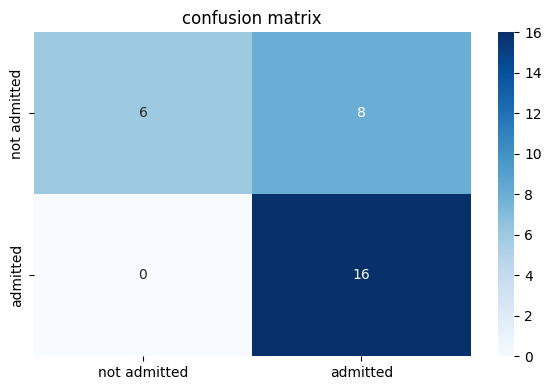

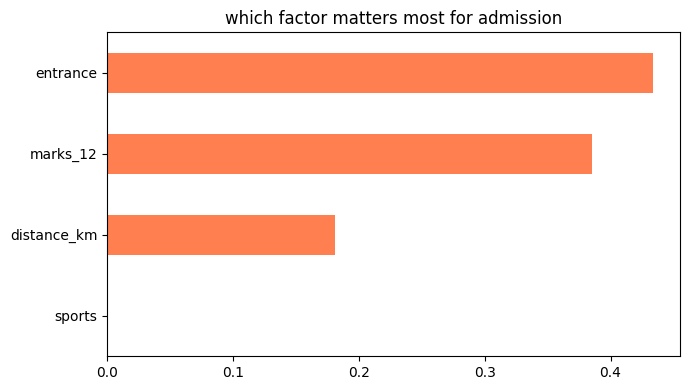

new student prediction: admitted
probability: 0.938


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

np.random.seed(42)
n = 150

data = {
    "marks_12":    np.random.randint(50, 100, n),
    "entrance":    np.random.randint(40, 100, n),
    "sports":      np.random.choice([0, 1], n),
    "distance_km": np.random.randint(5, 500, n),
    "admitted":    np.random.choice([0, 1], n, p=[0.4, 0.6])
}

df = pd.DataFrame(data)

x = df.drop("admitted", axis=1)
y = df["admitted"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("student admission prediction")
print("-" * 35)
print("train accuracy:", round(model.score(x_train, y_train), 3))
print("test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("-" * 35)
print(classification_report(y_test, y_pred,
      target_names=["not admitted", "admitted"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["not admitted", "admitted"],
            yticklabels=["not admitted", "admitted"])
plt.title("confusion matrix")
plt.tight_layout()
plt.show()

importance = pd.Series(model.feature_importances_, index=x.columns)
importance.sort_values().plot(kind="barh", color="coral",
                               figsize=(7, 4))
plt.title("which factor matters most for admission")
plt.tight_layout()
plt.show()

new_student = [[85, 78, 1, 50]]
result = model.predict(new_student)
prob = model.predict_proba(new_student)
print("new student prediction:",
      "admitted" if result[0] == 1 else "not admitted")
print("probability:", round(prob[0][result[0]], 3))